# Paramétrage de l'environnement de travail et import des packages

In [4]:
import sys
from pathlib import Path

In [5]:
ROOT = Path.cwd().parents[0]

MODEL_DATA = ROOT / "04_model"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import pandas as pd
import numpy as np
import shap
from fonctions_perso.machine_learning import waterfall_plot
import joblib
from sklearn import set_config

# Interpretation - SHAP

**Import de x_test | y_test et du modèle non calibré**

In [7]:
# x_test
x_test = joblib.load(PROCESSED_DATA / "x_test_for_shap.joblib")

# y_test
y_test = joblib.load(PROCESSED_DATA / "y_test_for_shap.joblib")

# modèle
modele = joblib.load(MODEL_DATA / "fraud_detection_xgb_pas_calibre.joblib")

In [8]:
full_test = pd.concat([x_test,y_test], axis = 1)

**Initialisation**

In [ ]:
set_config(transform_output="pandas")

# Appliquer toutes les étapes sans le modèle
x_test_proc = modele[:-1].transform(x_test)

# Récuperer le modèle "nu"
xgb = modele.named_steps["model"]

# Initialisation de l'explainer
explainer = shap.TreeExplainer(xgb, x_test_proc)

shap_values = explainer(x_test_proc)

100%|===================| 281240/281521 [10:54<00:00]        

**Sauvegarde des objets**

In [16]:
joblib.dump(shap_values, MODEL_DATA / "shap_values_model.joblib")

['c:\\Users\\user\\Desktop\\data_science_documents\\data_science_projets_perso\\projet_fraud_detection\\fraud-detection\\04_model\\shap_values_model.joblib']

In [ ]:
# shap_values = joblib.load(MODEL_DATA / "shap_values_model.joblib")

**Feature Importance**

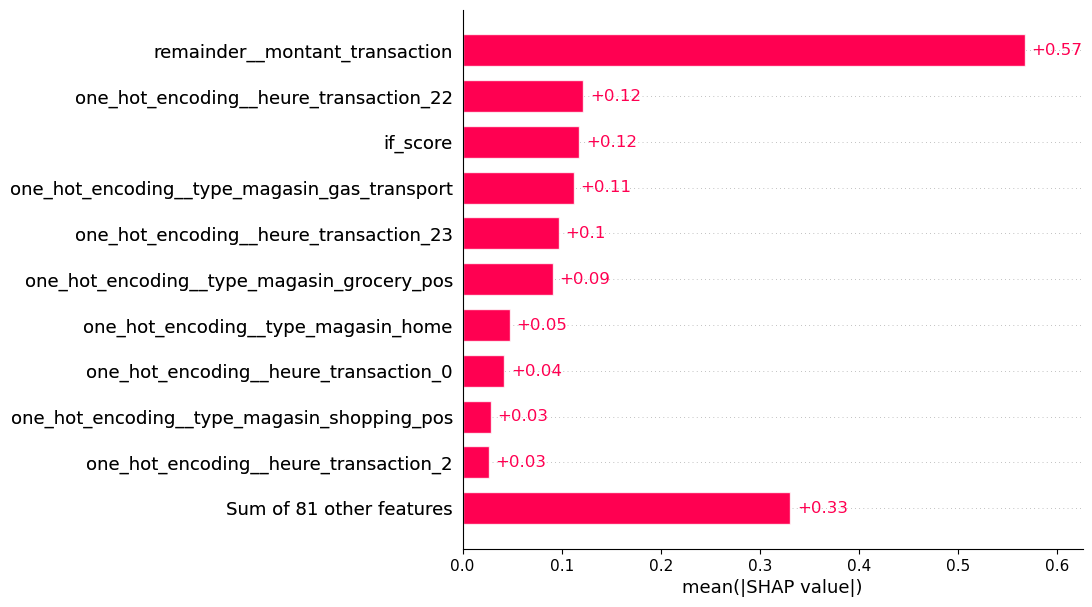

In [11]:
shap.plots.bar(shap_values, max_display=11)

**Beeswarm Plot**

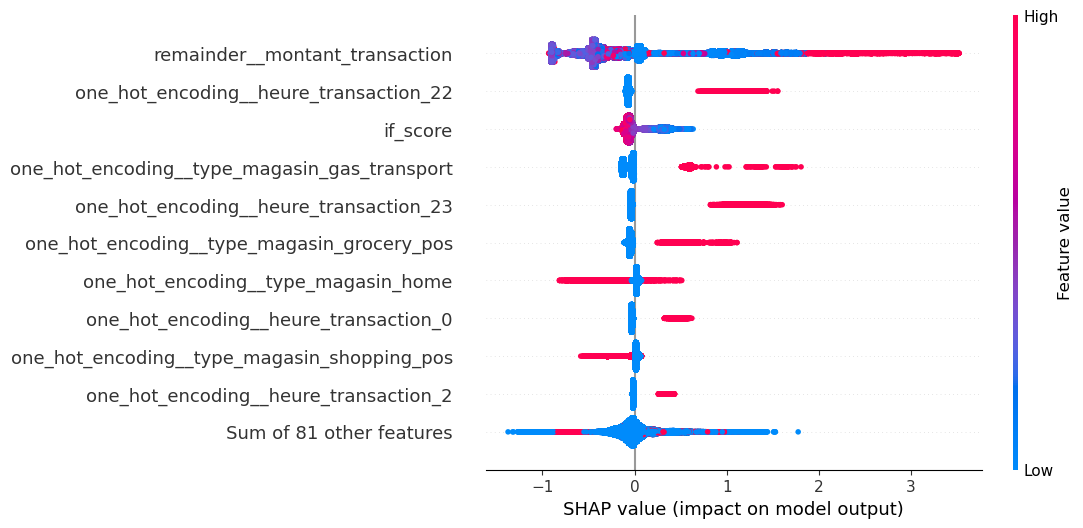

In [12]:
shap.plots.beeswarm(shap_values, max_display=11)

**Waterfall Plot**

Quelles explications pour une transaction légitime ?

In [19]:
full_test[full_test["target"]==0].sample(5)

,type_magasin,montant_transaction,etat_client,population_ville_client,heure_transaction,distance_domicile_magasin,age_client,target
540614,travel,5.52,PA,3688,16,55.589605,47,0
274806,misc_pos,1.33,other,601723,10,89.115200,50,0
500226,entertainment,46.69,GA,3430,2,57.998816,70,0
424005,food_dining,24.45,NE,206,15,62.971823,53,0
365189,misc_pos,6.11,FL,217,22,102.961485,30,0


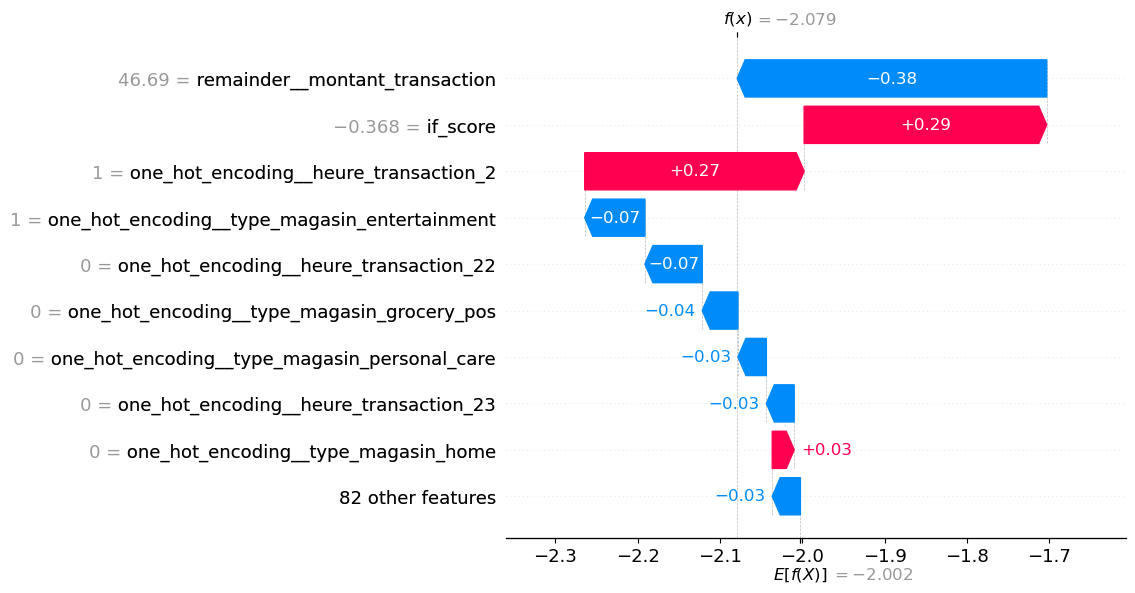

In [21]:
waterfall_plot(
    shap_values,
    x_test_proc,
    500226,
    max_display=10
)

Quelles explications pour une transaction frauduleuse ?

In [22]:
full_test[full_test["target"]==1].sample(5)

,type_magasin,montant_transaction,etat_client,population_ville_client,heure_transaction,distance_domicile_magasin,age_client,target
495791,shopping_net,835.63,other,601723,22,65.185761,50,1
357366,shopping_net,1009.40,ID,4154,22,128.677156,58,1
305879,kids_pets,16.75,MN,771,20,65.950075,48,1
333551,grocery_pos,302.51,GA,3430,0,102.120525,70,1
371721,entertainment,507.07,MI,937,22,94.997889,62,1


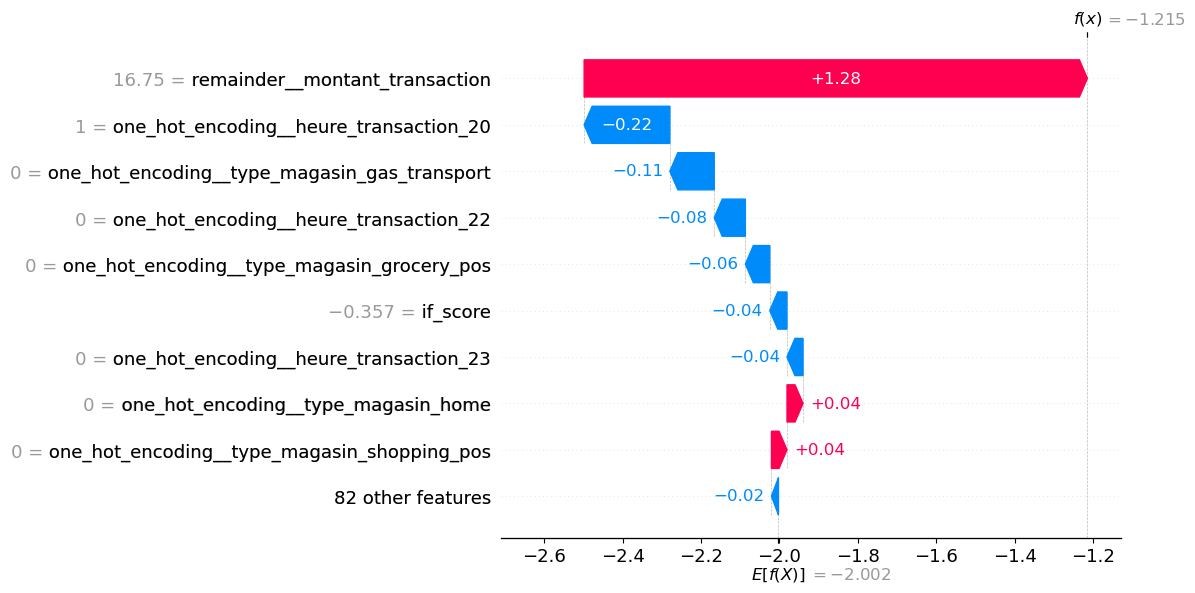

In [23]:
waterfall_plot(
    shap_values,
    x_test_proc,
    305879,
    max_display=10
)

# Note explicative du Notebook 